# Practice Project – Customer Churn Prediction System
Requirements
1. Preprocess dataset
2. Train:
- [Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [Decision Tree](https://scikit-learn.org/stable/modules/tree.html)
- Random Forest :[1.11. Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html)
3. Compare models
4. Evaluate:

For classification models:
- a. [Confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
- b. [Receiver Operating Characteristic(ROC) curve](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html)
- c. Precision/Recall tradeoff :[Precision-Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#precision-recall)

For regression models:
- a. MAE,
- b. MAPE,
- c. MSE
5. Feature importance analysis

## Biblioteci folostie

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# 1.Preprocess dataset
### Importarea datelor 

In [2]:
data_for_training = pd.read_csv("customer_churn_dataset\\customer_churn_dataset-training-master.csv")

data_for_testing = pd.read_csv("customer_churn_dataset\\customer_churn_dataset-testing-master.csv")

In [3]:
data_for_training

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [4]:
data_for_testing

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [5]:
data_for_training.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

### Verificare duplicate 

In [6]:
data_for_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [7]:
data_for_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [8]:
data_for_training.duplicated().value_counts()

False    440833
Name: count, dtype: int64

In [9]:
data_for_testing.duplicated().value_counts()

False    64374
Name: count, dtype: int64

In [10]:
data_for_training.duplicated().sum()

np.int64(0)

In [11]:
data_for_training.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [12]:
data_for_training.dropna(inplace=True)

In [13]:
data_for_training.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [14]:
data_for_training.drop(columns=["CustomerID"],inplace=True)
data_for_testing.drop(columns=["CustomerID"],inplace=True)

In [15]:
data_for_training["Gender"].apply(lambda x:1 if x=="Male" else 0)

0         0
1         0
2         0
3         1
4         1
         ..
440828    1
440829    0
440830    1
440831    1
440832    1
Name: Gender, Length: 440832, dtype: int64

In [16]:
data_for_training.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [17]:
data_for_training["Gender"]=data_for_training["Gender"].apply(lambda x:1 if x=="Male" else 0)

data_for_testing["Gender"]=data_for_testing["Gender"].apply(lambda x:1 if x=="Male" else 0)

In [18]:
data_for_training.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [19]:
data_for_training["Subscription Type"].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [20]:
data_for_training["Contract Length"].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [21]:
#* Annuall  =2 ;Quarterly = 1 ; Monthly = 0
data_for_training["Contract Length"]=data_for_training["Contract Length"].apply(lambda x:2 if x=="Annual" else(1 if x=="Quarterly" else 0))
data_for_testing["Contract Length"]=data_for_testing["Contract Length"].apply(lambda x:2 if x=="Annual" else(1 if x=="Quarterly" else 0))

In [22]:
data_for_training.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  int64  
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  int64  
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), int64(2), str(1)
memory usage: 40.4 MB


In [23]:
data_for_testing

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,Basic,0,598,9,1
1,41,0,28,28,7,13,Standard,0,584,20,0
2,47,1,27,10,2,29,Premium,2,757,21,0
3,35,1,9,12,5,17,Premium,1,232,18,0
4,53,0,58,24,9,2,Standard,2,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45,0,33,12,6,21,Basic,1,947,14,1
64370,37,1,6,1,5,22,Standard,2,923,9,1
64371,25,1,39,14,8,30,Premium,0,327,20,1
64372,50,0,18,19,7,22,Standard,0,540,13,1


In [24]:
#Premium 2 Standard 1 si basic 0
data_for_training["Subscription Type"]=data_for_training["Subscription Type"].apply(lambda x:2 if x=="Premium" else(1 if x=="Standard" else 0 ))
data_for_testing["Subscription Type"]=data_for_testing["Subscription Type"].apply(lambda x:2 if x=="Premium" else(1 if x=="Standard" else 0 ))

In [25]:
data_for_testing["Subscription Type"]

0        0
1        1
2        2
3        2
4        1
        ..
64369    0
64370    1
64371    2
64372    1
64373    1
Name: Subscription Type, Length: 64374, dtype: int64

In [26]:
data_for_training["Subscription Type"].value_counts()

Subscription Type
1    149128
2    148678
0    143026
Name: count, dtype: int64

In [27]:
data_for_training.reindex()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0,0.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0,0.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0,0.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0,0.0


In [28]:
data_for_training.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

In [29]:
data_for_training[["Age",'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction']]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


In [30]:
#train
X_train =data_for_training[["Age", "Gender", 'Tenure', 'Usage Frequency', 'Support Calls','Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend','Last Interaction']]
y_train = data_for_training['Churn']

#test
X_test =data_for_testing[['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls','Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend','Last Interaction']]
y_test = data_for_testing['Churn']

In [31]:
X_train

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


In [32]:
y_train

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
440828    0.0
440829    0.0
440830    0.0
440831    0.0
440832    0.0
Name: Churn, Length: 440832, dtype: float64

In [33]:
X_train

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.00,17.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.00,6.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.00,3.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.00,29.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.00,20.0
...,...,...,...,...,...,...,...,...,...,...
440828,42.0,1,54.0,15.0,1.0,3.0,2,2,716.38,8.0
440829,25.0,0,8.0,13.0,1.0,20.0,2,2,745.38,2.0
440830,26.0,1,35.0,27.0,1.0,5.0,1,1,977.31,9.0
440831,28.0,1,55.0,14.0,2.0,0.0,1,1,602.55,2.0


### Standardizing the features

In [34]:
scaler_z = StandardScaler()
X_standardized_train = X_train.copy()
X_standardized_test = X_test.copy()

# X_standardized_train[["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]]=scaler_z.fit_transform(X_train[["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]])
features_to_standardized =["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Total Spend","Last Interaction"]

for features in features_to_standardized:
    X_standardized_train[features] = scaler_z.fit_transform(X_train[[features]])

for features in features_to_standardized:
    X_standardized_test[features] = scaler_z.fit_transform(X_test[[features]])

X_standardized_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,-0.753326,0,0.448760,-0.210511,0.454549,0.609620,1,2,1.247427,0.293052
1,2.059646,0,1.028278,-1.724562,2.083100,-0.601319,0,0,-0.309865,-0.986584
2,1.255940,0,-1.000036,-1.375166,0.780259,0.609620,0,1,-1.854698,-1.335575
3,1.497051,1,0.390808,0.604748,1.105969,-0.722413,1,0,-0.978462,1.689018
4,-1.315921,1,0.043097,0.488282,0.454549,-0.601319,0,0,-0.060698,0.642043


In [35]:
X_standardized_test.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,-1.434202,0,-0.409100,-0.122526,-0.449807,1.114538,0,0,0.218408,-0.752324
1,-0.069730,0,-0.233642,1.465424,0.513590,-0.467000,1,0,0.164742,0.521065
2,0.361155,1,-0.292128,-0.576225,-1.092072,1.340472,2,2,0.827900,0.636827
3,-0.500616,1,-1.344876,-0.349375,-0.128674,-0.015132,2,1,-1.184575,0.289540
4,0.792041,0,1.520939,1.011724,1.155855,-1.709637,1,2,-0.030756,0.289540


In [36]:
plt.style.use('petroff8')

<Axes: >

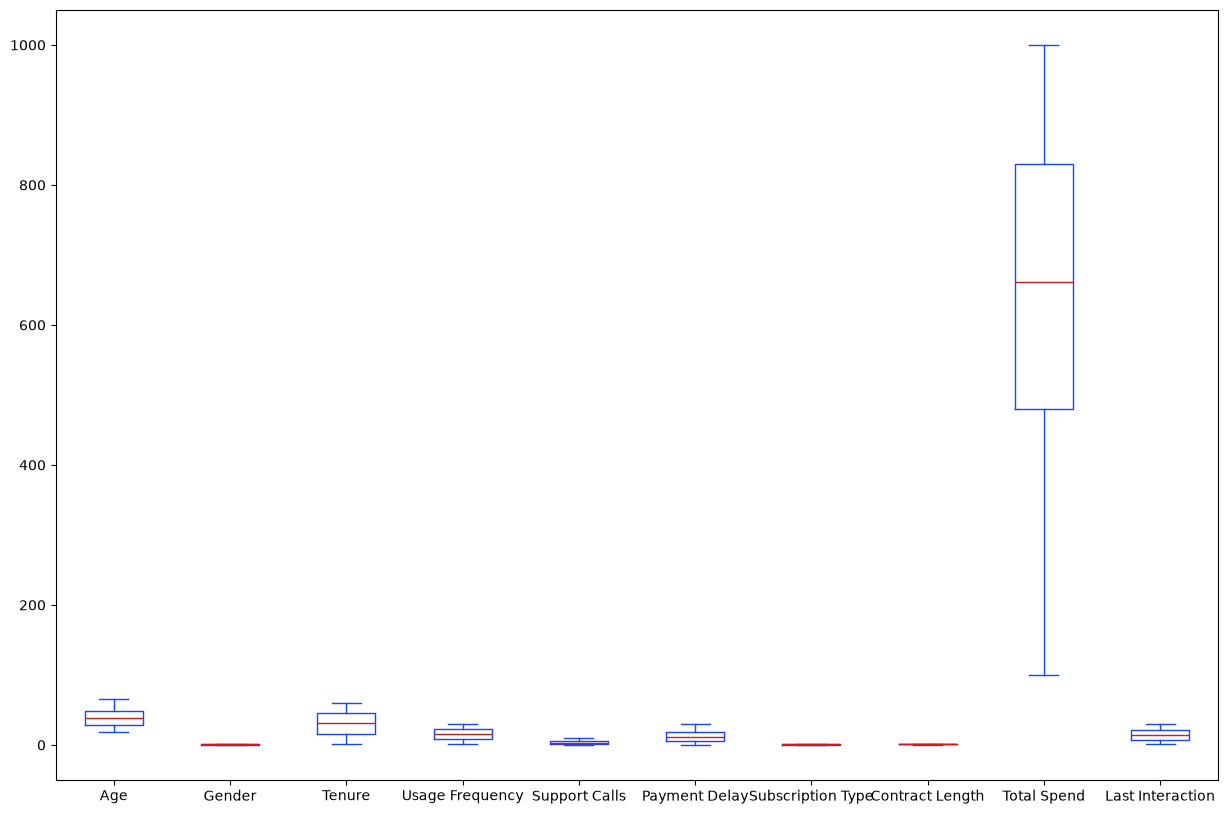

In [37]:

X_train.plot.box(figsize=(15,10))


<Axes: >

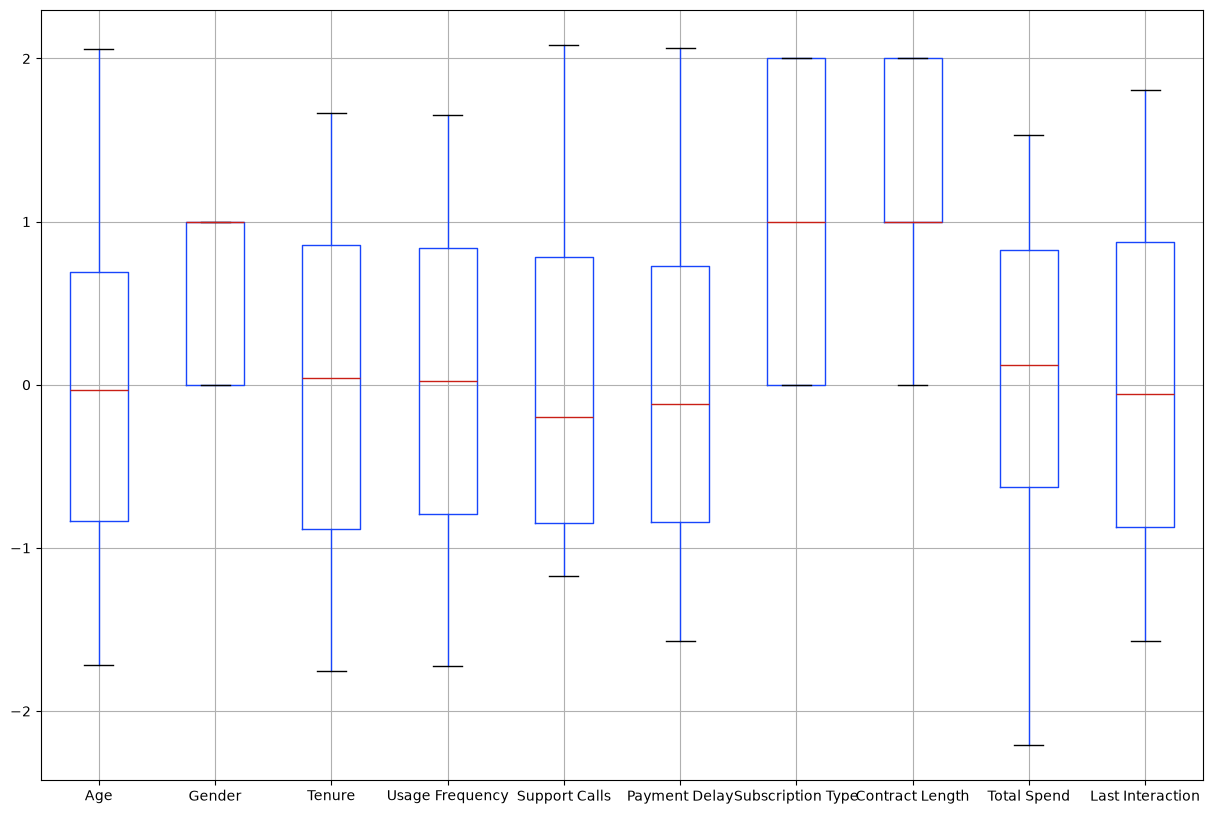

In [38]:
X_standardized_train.boxplot(figsize=(15,10))

In [39]:
X_standardized_train.describe()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
count,4.408320e+05,440832.000000,4.408320e+05,4.408320e+05,440832.000000,440832.000000,440832.000000,440832.000000,4.408320e+05,4.408320e+05
mean,8.252529e-17,0.567681,1.650506e-17,-3.301012e-17,0.000000,0.000000,1.012821,1.204373,-3.961214e-16,1.072829e-16
std,1.000001e+00,0.495399,1.000001e+00,1.000001e+00,1.000001,1.000001,0.813357,0.746851,1.000001e+00,1.000001e+00
min,-1.717774e+00,0.000000,-1.753410e+00,-1.724562e+00,-1.174002,-1.570070,0.000000,0.000000,-2.207684e+00,-1.568236e+00
25%,-8.336969e-01,0.000000,-8.841327e-01,-7.928383e-01,-0.848291,-0.843507,0.000000,1.000000,-6.296283e-01,-8.702531e-01
50%,-2.999058e-02,1.000000,4.309671e-02,2.242036e-02,-0.196871,-0.116943,1.000000,1.000000,1.220243e-01,-5.593961e-02
75%,6.933451e-01,1.000000,8.544225e-01,8.376790e-01,0.780259,0.730714,2.000000,2.000000,8.238436e-01,8.747044e-01
max,2.059646e+00,1.000000,1.665748e+00,1.652938e+00,2.083100,2.062747,2.000000,2.000000,1.529816e+00,1.805348e+00


In [40]:
X_train["Gender"].value_counts()

Gender
1    250252
0    190580
Name: count, dtype: int64

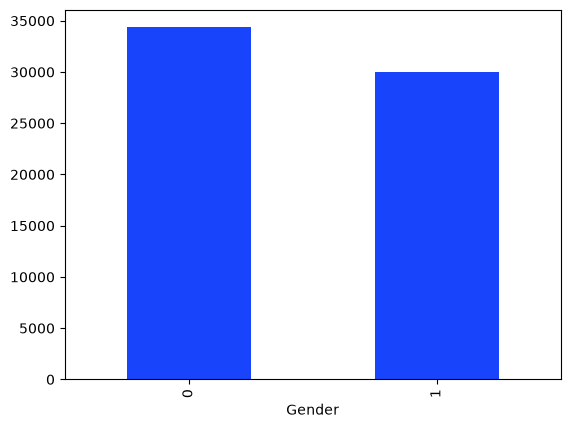

In [41]:
# Source - https://stackoverflow.com/a/55671161
# Posted by ImportanceOfBeingErnest
# Retrieved 2026-07-09, License - CC BY-SA 4.0

X_test["Gender"].value_counts().plot.bar()
plt.show()


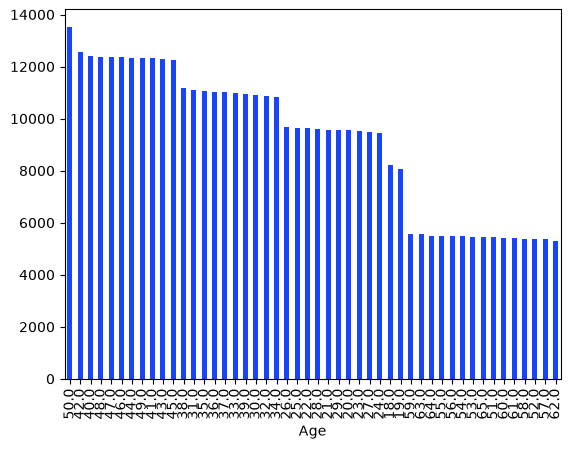

In [42]:
X_train["Age"].value_counts().plot.bar()
plt.show()

# 2. Train

## Logistic Regression

In [43]:
clf_logistic_regression= LogisticRegression(C=5,random_state=0).fit(X_train,y_train)


g:\facultate\anul 3 sem 2\Practica de specialiate\L3-IntroductionToMachineLearning\.venv_py3_12\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
clf_logistic_regression_stand = LogisticRegression(random_state=0).fit(X_standardized_train,y_train)


In [45]:
y_pred_log_reg_stand = clf_logistic_regression_stand.predict(X_standardized_test)

In [46]:
clf_logistic_regression_stand.predict_proba(X_standardized_test)

array([[0.09815386, 0.90184614],
       [0.01893022, 0.98106978],
       [0.90020186, 0.09979814],
       ...,
       [0.00221325, 0.99778675],
       [0.00583684, 0.99416316],
       [0.00158375, 0.99841625]], shape=(64374, 2))

0.8704222923925667

## Decision Trees

Classification

In [50]:
clf_decision_tree_stand = tree.DecisionTreeClassifier()
clf_decision_tree_stand = clf_decision_tree_stand.fit(X_standardized_train,y_train)
y_pred_decision_tree_class = clf_decision_tree_stand.predict(X_standardized_test)

[Text(0.6403702445652174, 0.96875, 'x[4] <= 0.292\ngini = 0.491\nsamples = 440832\nvalue = [190833.0, 249999.0]'),
 Text(0.340523097826087, 0.90625, 'x[8] <= -0.547\ngini = 0.462\nsamples = 297401\nvalue = [189516, 107885]'),
 Text(0.4904466711956522, 0.9375, 'True  '),
 Text(0.07744565217391304, 0.84375, 'x[8] <= -0.547\ngini = 0.0\nsamples = 52821\nvalue = [6, 52815]'),
 Text(0.06657608695652174, 0.78125, 'gini = 0.0\nsamples = 52699\nvalue = [0, 52699]'),
 Text(0.08831521739130435, 0.78125, 'x[5] <= -1.025\ngini = 0.094\nsamples = 122\nvalue = [6, 116]'),
 Text(0.03940217391304348, 0.71875, 'x[0] <= -0.231\ngini = 0.391\nsamples = 15\nvalue = [4, 11]'),
 Text(0.028532608695652172, 0.65625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.050271739130434784, 0.65625, 'x[3] <= -1.492\ngini = 0.26\nsamples = 13\nvalue = [2, 11]'),
 Text(0.03940217391304348, 0.59375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.06114130434782609, 0.59375, 'x[2] <= 0.825\ngini = 0.153\nsamples 

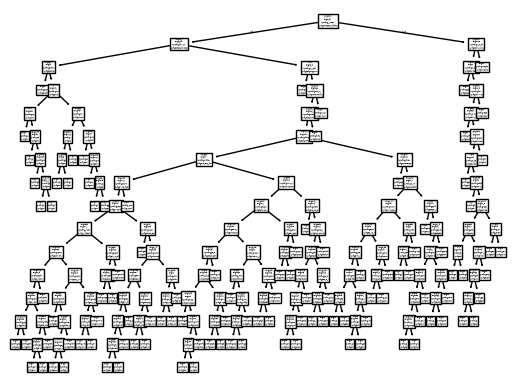

In [61]:
tree.plot_tree(clf_decision_tree_stand)

Date fără standardizare

In [51]:
clf_decision_tree = tree.DecisionTreeClassifier()

clf_decision_tree =clf_decision_tree.fit(X_train,y_train)


Regression

In [62]:
clf_decision_tree_reg = tree.DecisionTreeRegressor()
clf_decision_tree_reg = clf_decision_tree_reg.fit(X_standardized_train,y_train)

In [64]:
y_pred_decision_tree_reg= clf_decision_tree_reg.predict(X_standardized_test)

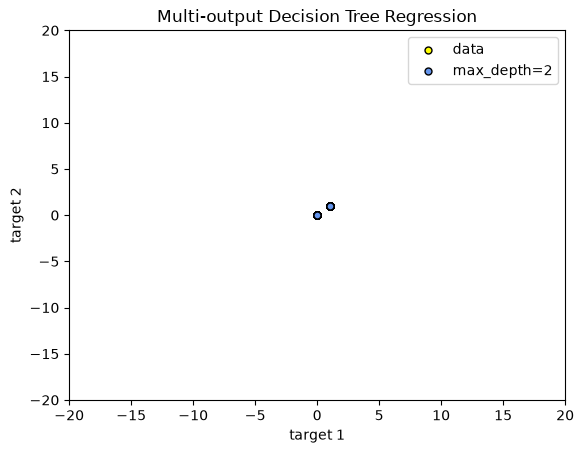

In [68]:
plt.figure()
s = 25
plt.scatter(y_train, y_train, c="yellow", s=s, edgecolor="black", label="data")
plt.scatter(
    y_pred_decision_tree_reg,
    y_pred_decision_tree_reg,
    c="cornflowerblue",
    s=s,
    edgecolor="black",
    label="max_depth=2",
)
# plt.scatter(y_2[:, 0], y_2[:, 1], c="red", s=s, edgecolor="black", label="max_depth=5")
# plt.scatter(y_3[:, 0], y_3[:, 1], c="blue", s=s, edgecolor="black", label="max_depth=8")
plt.xlim([-20, 20])
plt.ylim([-20, 20])
plt.xlabel("target 1")
plt.ylabel("target 2")
plt.title("Multi-output Decision Tree Regression")
plt.legend(loc="best")
plt.show()

## Random Forest

In [71]:
clf_random_forest = RandomForestClassifier()
clf_random_forest.fit(X_standardized_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
y_pred_rand_forest=clf_random_forest.predict(X_standardized_test)

# 3. Compare models

Score

In [75]:
clf_logistic_regression_stand.score(X_standardized_train,y_train)

0.8704222923925667

In [74]:
print(classification_report(y_test,y_pred_log_reg_stand))

              precision    recall  f1-score   support

           0       0.83      0.48      0.61     33881
           1       0.61      0.89      0.72     30493

    accuracy                           0.67     64374
   macro avg       0.72      0.68      0.66     64374
weighted avg       0.72      0.67      0.66     64374



# 4. Evaluate:

Logistic Regression

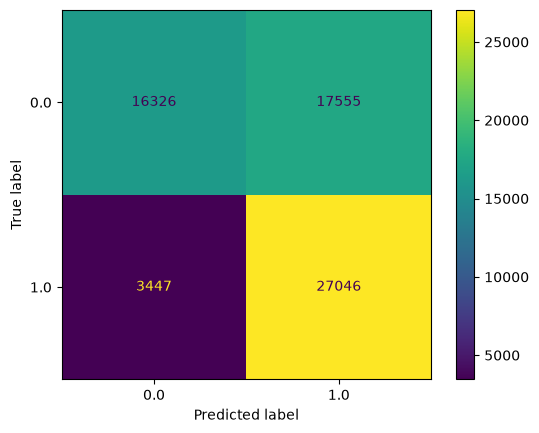

In [ ]:
cm_log_reg =confusion_matrix(y_test,y_pred_log_reg_stand)

disp_cm_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg,display_labels=clf_logistic_regression_stand.classes_)

disp_cm_log_reg.plot()

plt.show()

Decision Trees

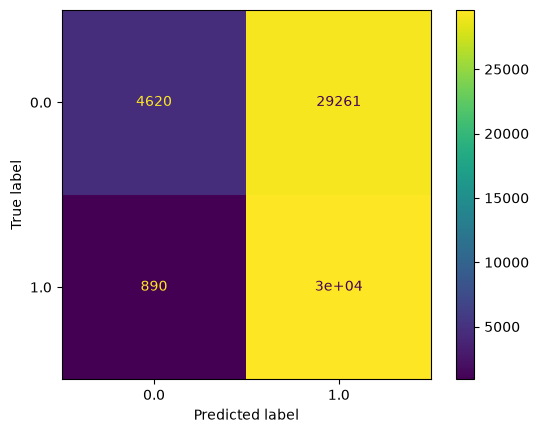

In [58]:
cm_decision_tree =confusion_matrix(y_test,y_pred_decision_tree_class)

disp_cm_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_decision_tree,display_labels=clf_decision_tree_stand.classes_)

disp_cm_log_reg.plot()

plt.show()

# Bibliografie
- [Customer Churn dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset?select=customer_churn_dataset-training-master.csv) 